# 📊 EDA PRELIMINAR - DATASET ESTUDIANTES

## 🎯 Objetivo
Realizar un análisis exploratorio inicial para:
- Comprender la estructura de los datos
- Detectar problemas de calidad (nulos, tipos de datos, valores inconsistentes)
- Identificar variables clave para el análisis posterior

Dataset principal: 
- dataset_estudiantes.csv

## 1. Carga e inspección inicial de los datos

En esta primera fase se carga el conjunto de datos y se realiza una inspección inicial para conocer su estructura general.  
El objetivo es revisar el número de filas y columnas, los tipos de variables disponibles, la existencia de valores nulos y una primera muestra del contenido del dataset.

Este paso es importante porque permite detectar posibles problemas de calidad de datos antes de aplicar técnicas de preprocesamiento o entrenar modelos de Machine Learning.

En primer lugar, instalo la librería scikit-learn


In [6]:
# Instalo scikit-learn 
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# A continuación, importamos las librerías necesarias para poder realizar el trabajo.

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)

In [8]:
# Carga de datos
df = pd.read_csv("../data/raw/dataset_estudiantes.csv")

# Mostrar primeras filas
df.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,tiene_tutor,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado
0,8.957476,48.830601,86.640182,6.675694,25,Fácil,Sí,Tarde,Lectura/Escritura,84.4,1
1,11.042524,80.825707,83.449655,4.616844,18,Difícil,No,Tarde,NaN,72.0,1
2,4.510776,90.383694,74.623607,7.755246,25,Fácil,No,Mañana,Lectura/Escritura,80.0,1
3,6.647213,81.878257,82.849841,8.592826,23,Fácil,No,NaN,Visual,78.2,1
4,1.000000,66.254179,54.539935,6.671840,21,Medio,No,NaN,Auditivo,66.0,1


In [9]:
# Información general del DataFrame
df.info()

print('=' * 50)
print(f'Nuestro archivo de datos "dataset_estudiantes" presenta un total de {df.shape[0]} filas y {df.shape[1]} columnas')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   horas_estudio_semanal      1000 non-null   float64
 1   nota_anterior              1000 non-null   float64
 2   tasa_asistencia            1000 non-null   float64
 3   horas_sueno                850 non-null    float64
 4   edad                       1000 non-null   int64  
 5   nivel_dificultad           1000 non-null   object 
 6   tiene_tutor                1000 non-null   object 
 7   horario_estudio_preferido  900 non-null    object 
 8   estilo_aprendizaje         950 non-null    object 
 9   nota_final                 1000 non-null   float64
 10  aprobado                   1000 non-null   int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 86.1+ KB
Nuestro archivo de datos "dataset_estudiantes" presenta un total de 1000 filas y 11 columnas


In [10]:
# Resumen de columnas, tipos de datos y valores no nulos
resumen_columnas = pd.DataFrame({
    "columna": df.columns,
    "tipo_dato": df.dtypes.values,
    "valores_no_nulos": df.notnull().sum().values,
    "valores_nulos": df.isnull().sum().values,
    "porcentaje_nulos": (df.isnull().mean().values * 100).round(2)
})

resumen_columnas

,columna,tipo_dato,valores_no_nulos,valores_nulos,porcentaje_nulos
0,horas_estudio_semanal,float64,1000,0,0.0
1,nota_anterior,float64,1000,0,0.0
2,tasa_asistencia,float64,1000,0,0.0
3,horas_sueno,float64,850,150,15.0
4,edad,int64,1000,0,0.0
5,nivel_dificultad,object,1000,0,0.0
6,tiene_tutor,object,1000,0,0.0
7,horario_estudio_preferido,object,900,100,10.0
8,estilo_aprendizaje,object,950,50,5.0
9,nota_final,float64,1000,0,0.0


### Observaciones iniciales


El dataset contiene variables numéricas y categóricas relacionadas con el rendimiento académico de estudiantes.

Las variables numéricas incluyen información como horas de estudio, nota anterior, tasa de asistencia, horas de sueño, edad y nota final.  
Las variables categóricas describen características como el nivel de dificultad percibido, si el estudiante tiene tutor, el horario de estudio preferido y el estilo de aprendizaje.

En esta primera revisión también se observa la presencia de valores nulos en algunas columnas, por lo que será necesario analizarlos con más detalle durante la fase de preprocesamiento.


In [11]:
# Estadísticas descriptivas de las variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
horas_estudio_semanal,1000.0,10.072366,4.852218,1.0,6.627548,10.000000,13.372452,25.0
nota_anterior,1000.0,69.885456,14.687697,30.0,59.882644,70.000000,80.117356,100.0
tasa_asistencia,1000.0,73.992079,18.195948,20.0,61.510192,75.000000,88.489808,100.0
horas_sueno,850.0,7.007670,1.444790,4.0,5.995341,7.020701,8.018834,10.0
edad,1000.0,23.532000,3.476933,18.0,21.000000,24.000000,27.000000,29.0
nota_final,1000.0,71.441400,9.562078,30.0,64.775000,71.400000,77.900000,100.0
aprobado,1000.0,0.898000,0.302800,0.0,1.000000,1.000000,1.000000,1.0


### Estadísticas descriptivas

Las estadísticas descriptivas permiten analizar el comportamiento general de las variables numéricas del dataset.  
A través de medidas como la media, desviación estándar, valores mínimos, máximos y cuartiles, es posible detectar posibles valores extremos, rangos poco habituales o diferencias importantes entre variables.

Este análisis es especialmente relevante antes del entrenamiento de los modelos, ya que algunas variables podrían requerir tratamiento adicional durante el preprocesamiento.


In [12]:
# Identificación de variables numéricas y categóricas
variables_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
variables_categoricas = df.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas:
['horas_estudio_semanal', 'nota_anterior', 'tasa_asistencia', 'horas_sueno', 'edad', 'nota_final', 'aprobado']

Variables categóricas:
['nivel_dificultad', 'tiene_tutor', 'horario_estudio_preferido', 'estilo_aprendizaje']


### Identificación de tipos de variables

Para preparar correctamente los datos, se separan las variables numéricas y categóricas.  
Esta distinción es necesaria porque cada tipo de variable requiere un tratamiento diferente durante el preprocesamiento.

Las variables numéricas pueden utilizarse directamente en los modelos, aunque en algunos casos será recomendable escalarlas.  
Las variables categóricas deberán transformarse posteriormente mediante técnicas de codificación, como One-Hot Encoding, para que puedan ser interpretadas por los algoritmos de Machine Learning.

In [13]:
# Cálculo de valores nulos por columna
valores_nulos = pd.DataFrame({
    "valores_nulos": df.isnull().sum(),
    "porcentaje_nulos": (df.isnull().mean() * 100).round(2)
})

# Mostrar solo columnas con valores nulos
valores_nulos[valores_nulos["valores_nulos"] > 0]

,valores_nulos,porcentaje_nulos
horas_sueno,150,15.0
horario_estudio_preferido,100,10.0
estilo_aprendizaje,50,5.0


### Análisis de valores nulos

El análisis de valores nulos permite identificar columnas con información incompleta.  
Estos valores deben tratarse antes del entrenamiento de los modelos, ya que muchos algoritmos de Machine Learning no aceptan datos ausentes.

En este caso, se revisan tanto el número absoluto de valores nulos como su porcentaje respecto al total de registros del dataset.  
Esta información ayudará a decidir si conviene imputar los valores faltantes, eliminarlos o aplicar otra estrategia de tratamiento.

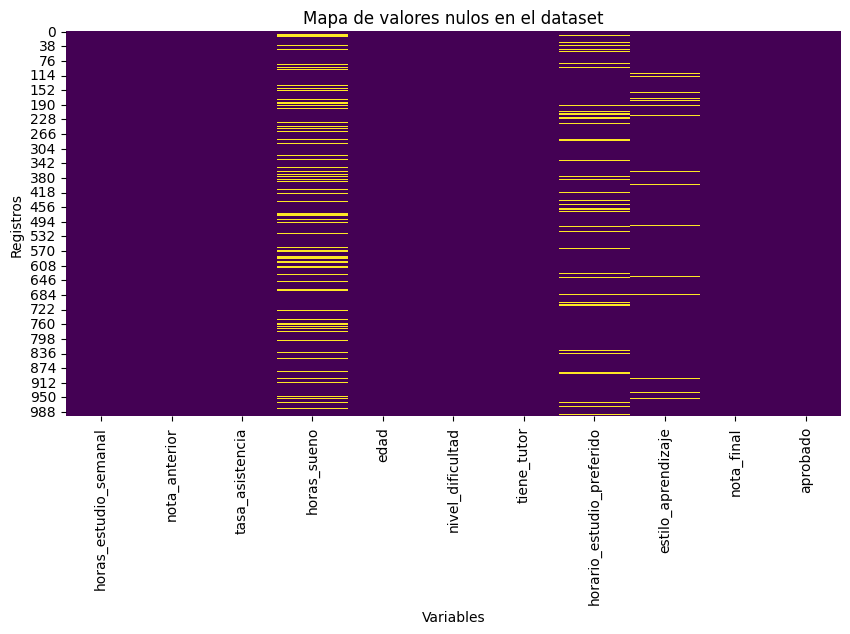

In [14]:
# Visualización de valores nulos
plt.figure(figsize=(10, 5))

sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title("Mapa de valores nulos en el dataset")
plt.xlabel("Variables")
plt.ylabel("Registros")

plt.show()

### Visualización de valores nulos

El mapa de valores nulos permite observar de forma visual en qué columnas aparecen datos ausentes y cómo se distribuyen a lo largo del dataset.

Esta representación facilita detectar si los valores nulos aparecen de forma aislada o si siguen algún patrón concreto dentro de los registros.

In [15]:
# Comprobación de registros duplicados
duplicados = df.duplicated().sum()

print(f"Número de registros duplicados: {duplicados}")

Número de registros duplicados: 0


### Análisis de duplicados

También se comprueba si existen registros duplicados en el dataset.  
Los duplicados pueden afectar negativamente al entrenamiento de los modelos, ya que pueden introducir sesgos o dar más peso a determinados registros.

En caso de encontrar duplicados, se valorará su eliminación durante la fase de preprocesamiento.

In [16]:
# Estadísticas descriptivas de variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
horas_estudio_semanal,1000.0,10.072366,4.852218,1.0,6.627548,10.000000,13.372452,25.0
nota_anterior,1000.0,69.885456,14.687697,30.0,59.882644,70.000000,80.117356,100.0
tasa_asistencia,1000.0,73.992079,18.195948,20.0,61.510192,75.000000,88.489808,100.0
horas_sueno,850.0,7.007670,1.444790,4.0,5.995341,7.020701,8.018834,10.0
edad,1000.0,23.532000,3.476933,18.0,21.000000,24.000000,27.000000,29.0
nota_final,1000.0,71.441400,9.562078,30.0,64.775000,71.400000,77.900000,100.0
aprobado,1000.0,0.898000,0.302800,0.0,1.000000,1.000000,1.000000,1.0


In [17]:
# Identificación de variables numéricas y categóricas
variables_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
variables_categoricas = df.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas:
['horas_estudio_semanal', 'nota_anterior', 'tasa_asistencia', 'horas_sueno', 'edad', 'nota_final', 'aprobado']

Variables categóricas:
['nivel_dificultad', 'tiene_tutor', 'horario_estudio_preferido', 'estilo_aprendizaje']


In [18]:
# Análisis de valores nulos
valores_nulos = pd.DataFrame({
    "valores_nulos": df.isnull().sum(),
    "porcentaje_nulos": (df.isnull().mean() * 100).round(2)
})

valores_nulos[valores_nulos["valores_nulos"] > 0]

,valores_nulos,porcentaje_nulos
horas_sueno,150,15.0
horario_estudio_preferido,100,10.0
estilo_aprendizaje,50,5.0


## 2. Análisis univariante de variables numéricas

En esta parte o sección del notebook, se analiza de forma individual la distribución de las variables numéricas del dataset.

El objetivo es comprender el comportamiento de cada variable, revisar sus rangos de valores, detectar posibles asimetrías y observar si existen valores extremos que puedan influir posteriormente en el entrenamiento de los modelos.

Este análisis es importante porque permite conocer mejor la información disponible antes de aplicar técnicas de preprocesamiento y construir los modelos de regresión y clasificación.

### 2.1 Selección de variables numéricas

Para el análisis univariante se seleccionan las variables numéricas continuas del dataset.

Aunque la variable `aprobado` también está almacenada como numérica, representa una variable binaria, por lo que se analizará de forma separada más adelante.

Las variables numéricas continuas permiten estudiar aspectos como las horas de estudio, la nota anterior, la asistencia, las horas de sueño, la edad y la nota final de los estudiantes.

In [19]:
# Selección de variables numéricas continuas para el análisis univariante
variables_numericas_continuas = [
    "horas_estudio_semanal",
    "nota_anterior",
    "tasa_asistencia",
    "horas_sueno",
    "edad",
    "nota_final"
]

# Mostramos las variables seleccionadas
variables_numericas_continuas

['horas_estudio_semanal',
 'nota_anterior',
 'tasa_asistencia',
 'horas_sueno',
 'edad',
 'nota_final']

### 2.2 Representación gráfica de las variables numéricas

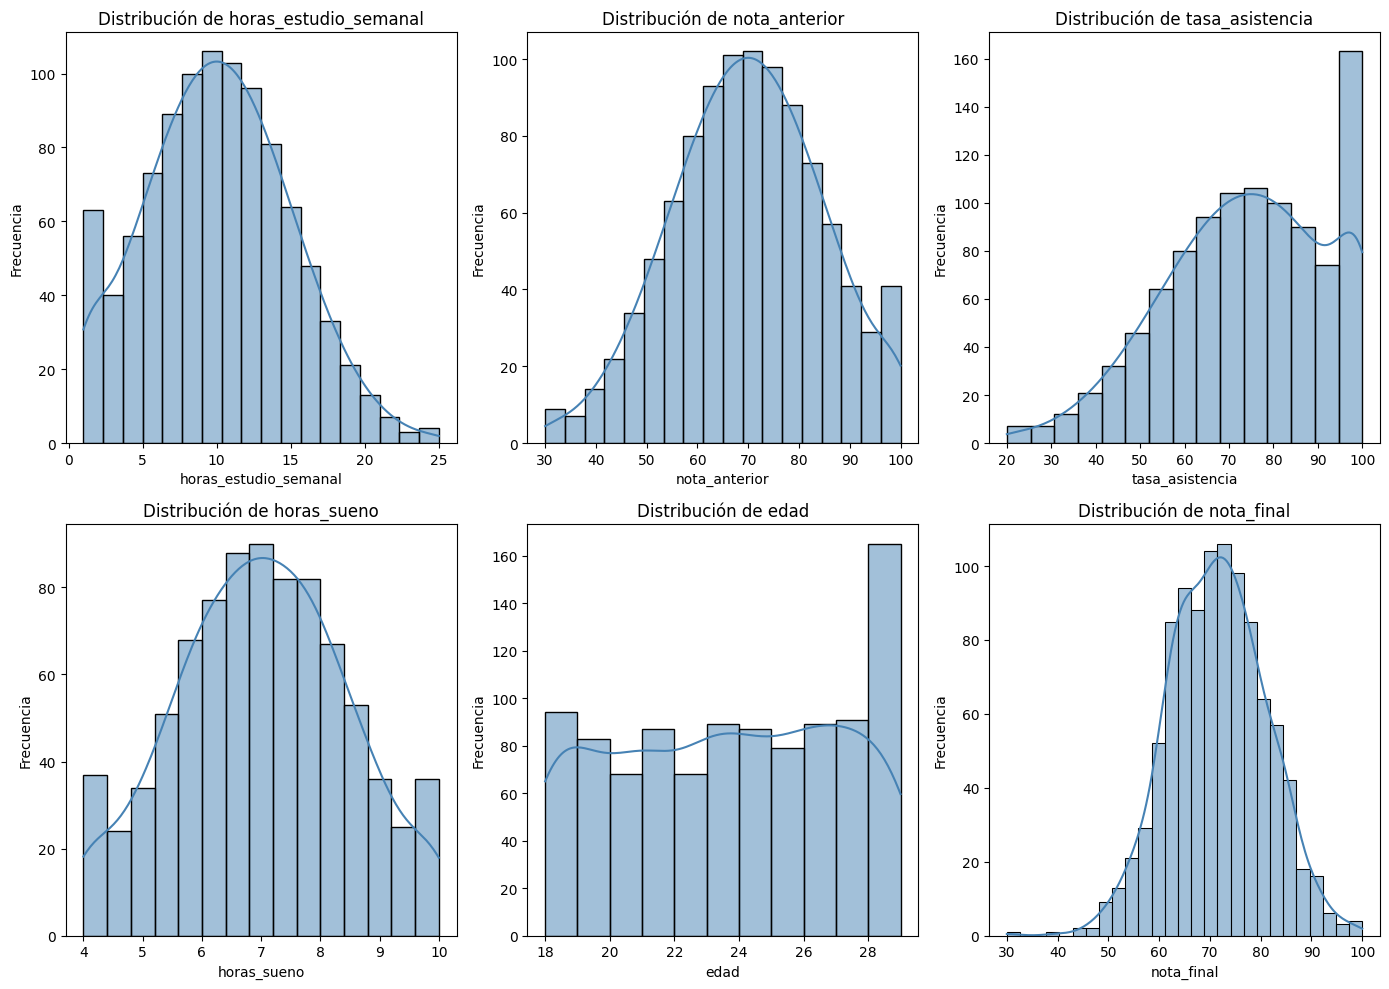

In [20]:
# Visualización de la distribución de las variables numéricas continuas
plt.figure(figsize=(14, 10))

for i, columna in enumerate(variables_numericas_continuas, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data=df, x=columna, kde=True, color="steelblue")
    plt.title(f"Distribución de {columna}")
    plt.xlabel(columna)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()


### Distribución de las variables numéricas

Los histogramas permiten observar cómo se distribuyen las variables numéricas continuas del dataset.

A partir de estos gráficos se puede analizar si las variables presentan una distribución aproximadamente simétrica, si existen concentraciones de valores en determinados rangos o si aparecen posibles valores poco frecuentes.

Este análisis resulta especialmente relevante para `nota_final`, ya que será la variable objetivo del modelo de regresión lineal.

### 2.3 Análisis de valores extremos 

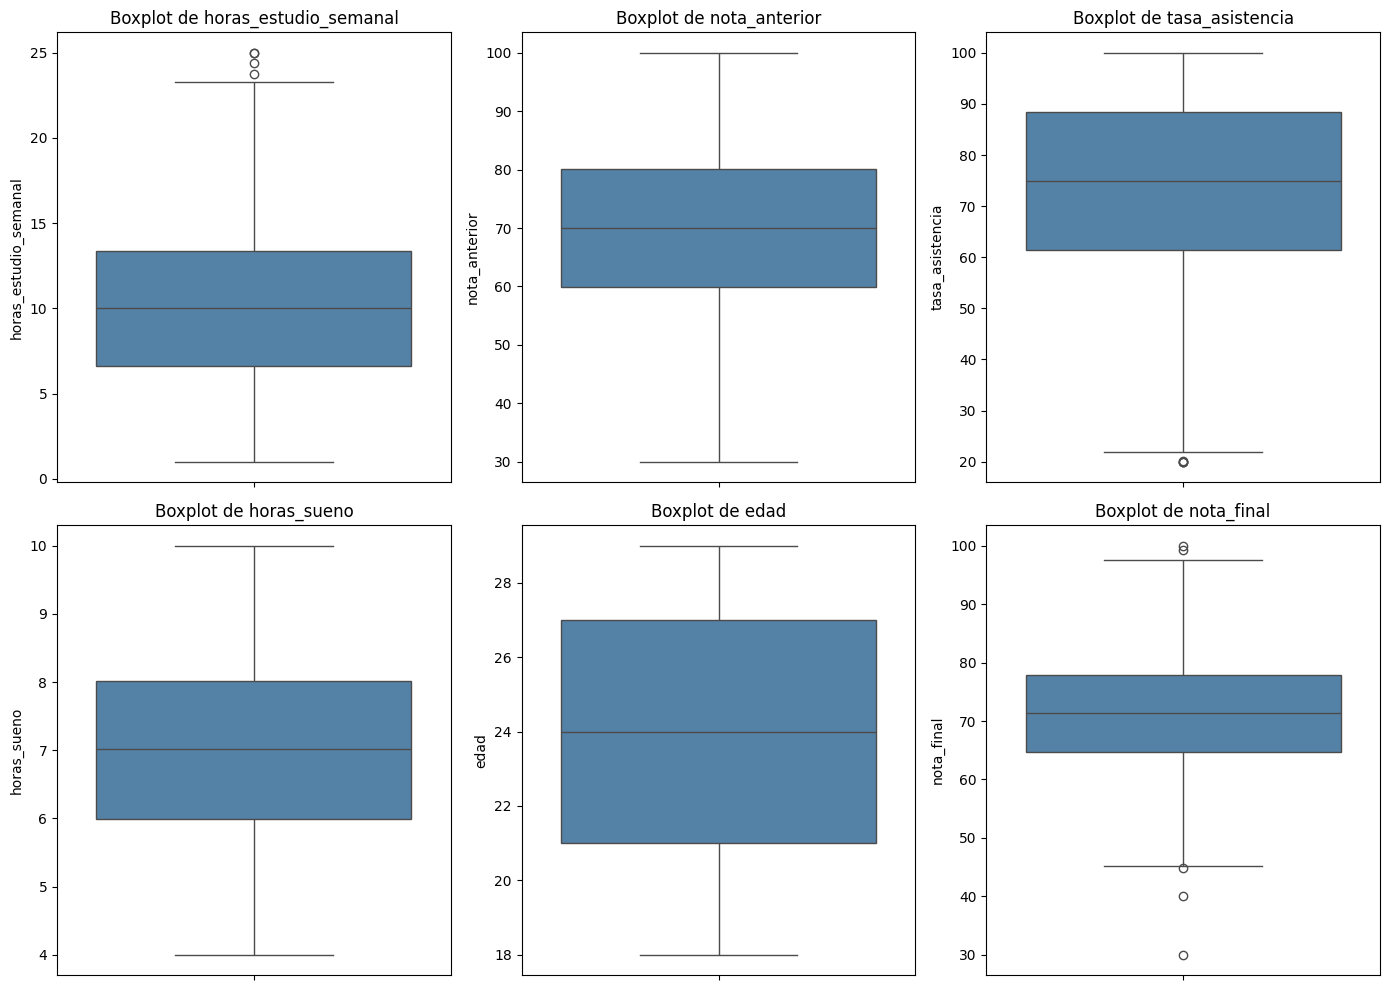

In [21]:
# Visualización de posibles valores extremos mediante boxplots
plt.figure(figsize=(14, 10))

for i, columna in enumerate(variables_numericas_continuas, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, y=columna, color="steelblue")
    plt.title(f"Boxplot de {columna}")
    plt.ylabel(columna)

plt.tight_layout()
plt.show()

### Detección visual de valores extremos

Los boxplots permiten identificar posibles valores extremos en las variables numéricas.

Estos gráficos muestran la mediana, el rango intercuartílico y los valores que se alejan del comportamiento central de cada variable.

En esta fase del análisis no se eliminan ni modifican estos valores. Únicamente se identifican para valorar más adelante, durante el preprocesamiento, si es necesario aplicar algún tratamiento específico.

### 2.4 Resumen estadístico 

In [22]:
# Resumen estadístico ampliado de las variables numéricas continuas
resumen_numericas = df[variables_numericas_continuas].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max",
    "skew"
]).T

# Redondeamos los valores para facilitar la lectura
resumen_numericas = resumen_numericas.round(2)

resumen_numericas

,count,mean,median,std,min,max,skew
horas_estudio_semanal,1000.0,10.07,10.00,4.85,1.0,25.0,0.18
nota_anterior,1000.0,69.89,70.00,14.69,30.0,100.0,-0.10
tasa_asistencia,1000.0,73.99,75.00,18.20,20.0,100.0,-0.40
horas_sueno,850.0,7.01,7.02,1.44,4.0,10.0,-0.02
edad,1000.0,23.53,24.00,3.48,18.0,29.0,-0.06
nota_final,1000.0,71.44,71.40,9.56,30.0,100.0,-0.02


### Resumen estadístico ampliado

El resumen estadístico ampliado permite analizar de forma más detallada las variables numéricas del dataset.

Además de las medidas habituales, como la media, la mediana, la desviación estándar, el mínimo y el máximo, se incorpora la asimetría mediante la métrica `skew`.

La asimetría ayuda a identificar si una variable se distribuye de forma equilibrada o si presenta una concentración mayor de valores hacia uno de los extremos.

### 2.5 Análisis específico de "nota_final"

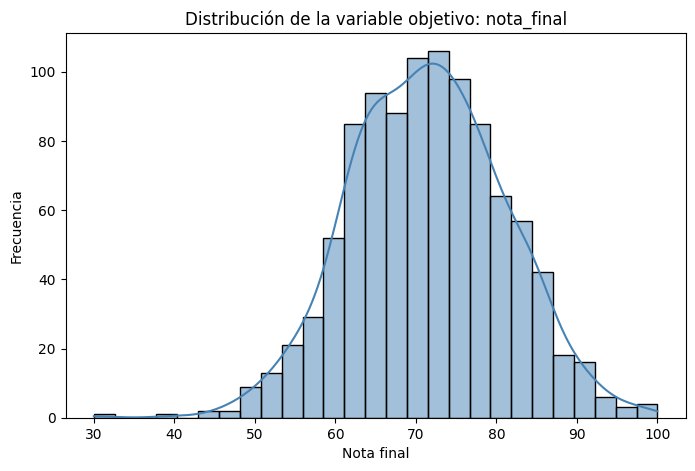

In [23]:
# Análisis específico de la variable objetivo de regresión: nota_final
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="nota_final", kde=True, color="steelblue")

plt.title("Distribución de la variable objetivo: nota_final")
plt.xlabel("Nota final")
plt.ylabel("Frecuencia")

plt.show()

In [24]:
# Estadísticas principales de la variable nota_final
df["nota_final"].describe().round(2)

count    1000.00
mean       71.44
std         9.56
min        30.00
25%        64.78
50%        71.40
75%        77.90
max       100.00
Name: nota_final, dtype: float64

### Variable objetivo de regresión: nota_final

La variable `nota_final` representa la nota final obtenida por cada estudiante y será la variable objetivo del modelo de regresión lineal.

Analizar su distribución permite comprobar si los valores se concentran en un rango concreto, si existen notas especialmente bajas o altas y si la variable presenta una variabilidad suficiente para ser modelizada.

Según la inspección inicial, `nota_final` presenta valores comprendidos entre 30 y 100 puntos, con una media aproximada situada en torno a 71 puntos. Esto indica que, en general, el rendimiento académico de los estudiantes se concentra en valores medios-altos.

### 2.6 Análisis específico de "aprobado"

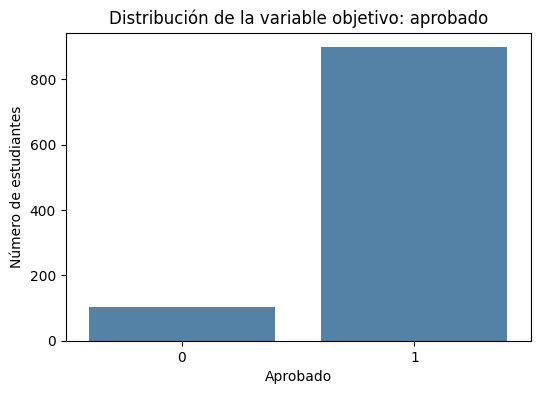

In [25]:
# Distribución de la variable objetivo de clasificación: aprobado
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="aprobado", color="steelblue")

plt.title("Distribución de la variable objetivo: aprobado")
plt.xlabel("Aprobado")
plt.ylabel("Número de estudiantes")

plt.show()

In [26]:
# Distribución absoluta y porcentual de la variable aprobado
distribucion_aprobado = pd.DataFrame({
    "frecuencia": df["aprobado"].value_counts(),
    "porcentaje": df["aprobado"].value_counts(normalize=True).mul(100).round(2)
})

distribucion_aprobado

,frecuencia,porcentaje
aprobado,,
1,898,89.8
0,102,10.2


### Variable objetivo de clasificación: aprobado

La variable `aprobado` indica si el estudiante ha superado o no la asignatura, tomando el valor 1 para los estudiantes aprobados y 0 para los no aprobados.

Esta variable será la variable objetivo del modelo de clasificación mediante regresión logística.

El análisis de su distribución permite comprobar si el conjunto de datos está equilibrado entre ambas clases. Esta revisión es importante porque un fuerte desequilibrio puede afectar a la interpretación de las métricas del modelo de clasificación.

En caso de que exista una proporción mucho mayor de estudiantes aprobados que no aprobados, será necesario complementar el accuracy con otras métricas como precision, recall, f1-score y matriz de confusión.

### 2.7 Conclusión parcial del análisis univariante numérico

El análisis univariante de las variables numéricas permite obtener una primera visión del comportamiento individual de cada variable.

Las variables relacionadas con el rendimiento académico, como `nota_anterior`, `tasa_asistencia`, `horas_estudio_semanal` y `nota_final`, serán especialmente relevantes en las siguientes fases del proyecto, ya que podrían estar relacionadas con el resultado académico de los estudiantes.

También se observa que `nota_final` tiene un rango amplio de valores, lo que la convierte en una variable adecuada para el modelo de regresión.

Por otro lado, la variable `aprobado` muestra la distribución de las clases del problema de clasificación. Esta información será importante más adelante para evaluar correctamente el modelo de regresión logística.

## 3. Análisis univariante de variables categóricas

En esta sección se analiza la distribución individual de las variables categóricas del dataset.

El objetivo es conocer las categorías presentes en cada variable, revisar la frecuencia de aparición de cada una y detectar posibles desequilibrios o valores ausentes.

Este análisis es relevante porque las variables categóricas deberán transformarse posteriormente durante el preprocesamiento para poder ser utilizadas por los modelos de Machine Learning.

### 3.1 Selección de variables categóricas

In [27]:
# Selección de variables categóricas del dataset
variables_categoricas = df.select_dtypes(include=["object"]).columns.tolist()

# Mostramos las variables categóricas identificadas
variables_categoricas

['nivel_dificultad',
 'tiene_tutor',
 'horario_estudio_preferido',
 'estilo_aprendizaje']

### Selección de variables categóricas

En primer lugar, se identifican las variables categóricas del dataset.

Estas variables contienen información no numérica relacionada con características de los estudiantes, como el nivel de dificultad percibido, la existencia de tutor, el horario de estudio preferido y el estilo de aprendizaje.

Estas variables no pueden introducirse directamente en la mayoría de modelos de Machine Learning, por lo que más adelante deberán codificarse durante la fase de preprocesamiento.

### 3.2 Frecuencia absoluta de cada variable categórica

In [28]:
# Análisis de frecuencias absolutas para las variables categóricas
for columna in variables_categoricas:
    print("=" * 50)
    print(f"Variable: {columna}")
    print(df[columna].value_counts(dropna=False))
    print()


# Recorre todas las variables categóricas.
# Muestra las categorías de cada variables.

Variable: nivel_dificultad
nivel_dificultad
Medio      504
Fácil      313
Difícil    183
Name: count, dtype: int64

Variable: tiene_tutor
tiene_tutor
No    597
Sí    403
Name: count, dtype: int64

Variable: horario_estudio_preferido
horario_estudio_preferido
Noche     344
Tarde     337
Mañana    219
NaN       100
Name: count, dtype: int64

Variable: estilo_aprendizaje
estilo_aprendizaje
Visual               363
Auditivo             254
Kinestésico          178
Lectura/Escritura    155
NaN                   50
Name: count, dtype: int64



### 3.3 Frecuencia porcentual de cada variable categórica

In [29]:
# Análisis de frecuencias porcentuales para las variables categóricas
for columna in variables_categoricas:
    print("=" * 50)
    print(f"Variable: {columna}")
    print(df[columna].value_counts(normalize=True, dropna=False).mul(100).round(2))
    print()

Variable: nivel_dificultad
nivel_dificultad
Medio      50.4
Fácil      31.3
Difícil    18.3
Name: proportion, dtype: float64

Variable: tiene_tutor
tiene_tutor
No    59.7
Sí    40.3
Name: proportion, dtype: float64

Variable: horario_estudio_preferido
horario_estudio_preferido
Noche     34.4
Tarde     33.7
Mañana    21.9
NaN       10.0
Name: proportion, dtype: float64

Variable: estilo_aprendizaje
estilo_aprendizaje
Visual               36.3
Auditivo             25.4
Kinestésico          17.8
Lectura/Escritura    15.5
NaN                   5.0
Name: proportion, dtype: float64



### Frecuencias porcentuales de las variables categóricas

Las frecuencias porcentuales permiten interpretar mejor el peso relativo de cada categoría dentro del dataset.

Este análisis es útil para detectar si una variable está equilibrada entre sus categorías o si existe una categoría dominante.

También permite valorar la importancia de los valores ausentes en cada variable categórica antes de decidir cómo tratarlos en la fase de preprocesamiento.

### 3.4 Tabla resumen de variables categóricas

In [30]:
# Resumen general de variables categóricas
resumen_categoricas = pd.DataFrame({
    "variable": variables_categoricas,
    "categorias_unicas": [df[col].nunique(dropna=True) for col in variables_categoricas],
    "valores_nulos": [df[col].isnull().sum() for col in variables_categoricas],
    "porcentaje_nulos": [(df[col].isnull().mean() * 100).round(2) for col in variables_categoricas],
    "categoria_mas_frecuente": [df[col].mode(dropna=True)[0] for col in variables_categoricas],
    "frecuencia_categoria_mas_frecuente": [df[col].value_counts(dropna=True).iloc[0] for col in variables_categoricas]
})

resumen_categoricas

,variable,categorias_unicas,valores_nulos,porcentaje_nulos,categoria_mas_frecuente,frecuencia_categoria_mas_frecuente
0,nivel_dificultad,3,0,0.0,Medio,504
1,tiene_tutor,2,0,0.0,No,597
2,horario_estudio_preferido,3,100,10.0,Noche,344
3,estilo_aprendizaje,4,50,5.0,Visual,363


### Resumen de variables categóricas

La tabla resumen permite observar de forma compacta las principales características de las variables categóricas.

Para cada variable se muestra el número de categorías distintas, la cantidad de valores nulos, el porcentaje de valores ausentes, la categoría más frecuente y su frecuencia.

Esta información será útil durante el preprocesamiento, especialmente para decidir cómo tratar los valores nulos y cómo codificar cada variable categórica.

### 3.5 Visualización de variables categóricas

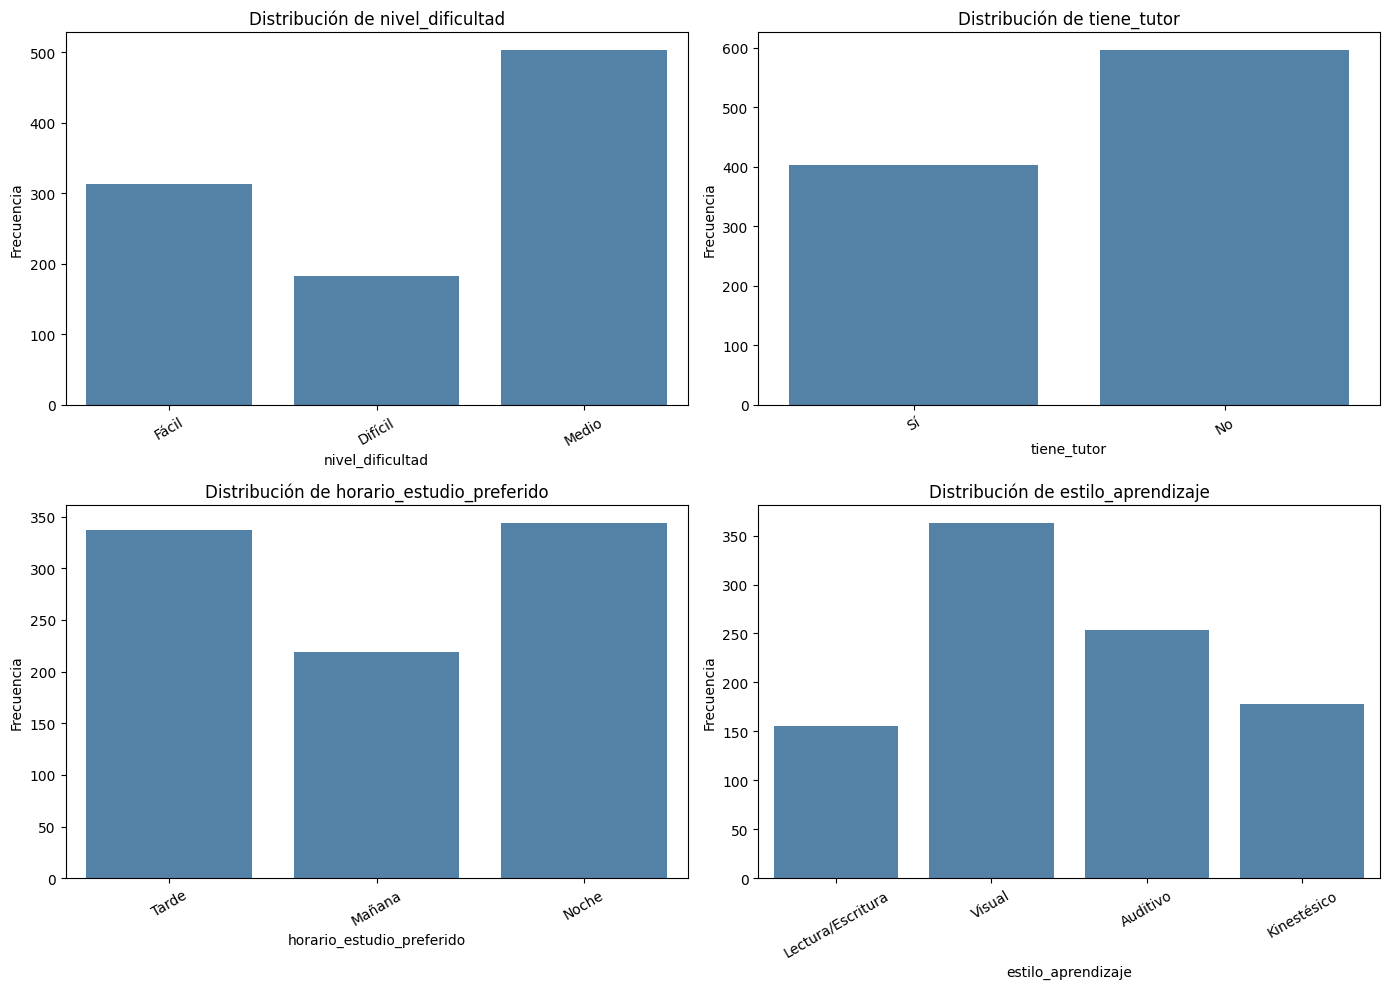

In [31]:
# Visualización de la distribución de las variables categóricas
plt.figure(figsize=(14, 10))

for i, columna in enumerate(variables_categoricas, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x=columna, color="steelblue")
    plt.title(f"Distribución de {columna}")
    plt.xlabel(columna)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Distribución visual de las variables categóricas

Los gráficos de barras permiten visualizar la frecuencia de cada categoría dentro de las variables categóricas.

Este tipo de gráfico facilita la detección de categorías dominantes, posibles desequilibrios y diferencias relevantes entre grupos.

La visualización de estas variables es especialmente importante antes de aplicar técnicas de codificación, ya que permite comprender mejor la información cualitativa disponible en el dataset.

### 3.6 Análisis indovidual de cada variable categórica

### Análisis individual de las variables categóricas

A continuación se revisa cada variable categórica de forma individual:

- `nivel_dificultad`: representa la dificultad percibida por el estudiante durante el estudio.
- `tiene_tutor`: indica si el estudiante cuenta con apoyo de un tutor.
- `horario_estudio_preferido`: recoge el momento del día preferido para estudiar.
- `estilo_aprendizaje`: describe la forma principal de aprendizaje del estudiante.

Estas variables pueden aportar información relevante para explicar diferencias en el rendimiento académico y, por tanto, podrían influir tanto en la predicción de la nota final como en la clasificación de aprobado o no aprobado.

### 3.7 Visualización individual con porcentajes.

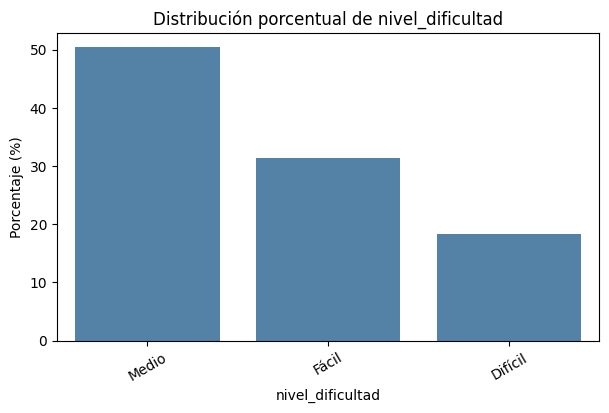

,nivel_dificultad,porcentaje
0,Medio,50.4
1,Fácil,31.3
2,Difícil,18.3


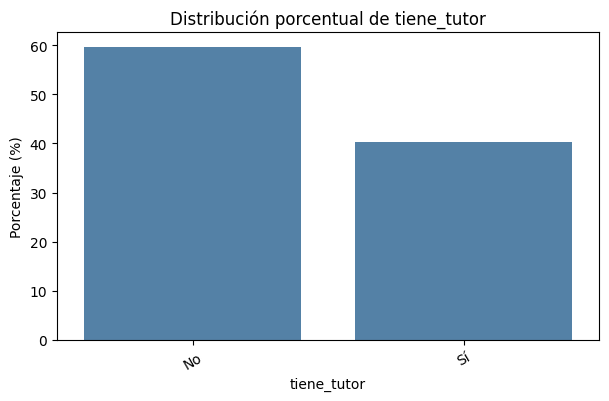

,tiene_tutor,porcentaje
0,No,59.7
1,Sí,40.3


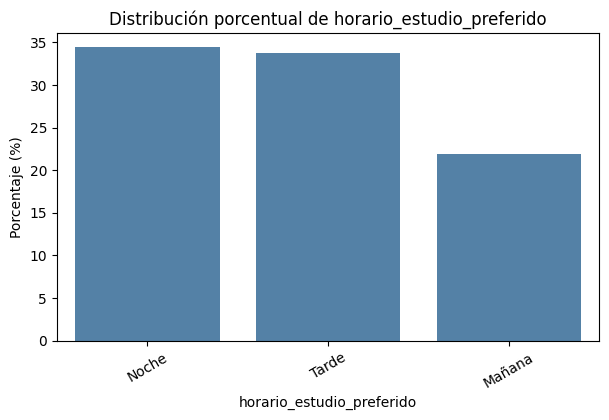

,horario_estudio_preferido,porcentaje
0,Noche,34.4
1,Tarde,33.7
2,Mañana,21.9
3,NaN,10.0


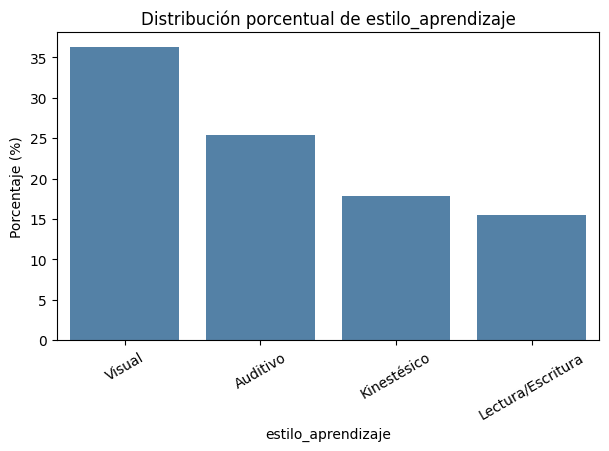

,estilo_aprendizaje,porcentaje
0,Visual,36.3
1,Auditivo,25.4
2,Kinestésico,17.8
3,Lectura/Escritura,15.5
4,NaN,5.0


In [32]:
# Visualización porcentual de cada variable categórica
for columna in variables_categoricas:
    tabla_porcentajes = (
        df[columna]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
        .reset_index()
    )
    
    tabla_porcentajes.columns = [columna, "porcentaje"]
    
    plt.figure(figsize=(7, 4))
    sns.barplot(data=tabla_porcentajes, x=columna, y="porcentaje", color="steelblue")
    
    plt.title(f"Distribución porcentual de {columna}")
    plt.xlabel(columna)
    plt.ylabel("Porcentaje (%)")
    plt.xticks(rotation=30)
    
    plt.show()
    
    display(tabla_porcentajes)

### Distribución porcentual de las variables categóricas

La distribución porcentual permite interpretar de forma más clara la importancia relativa de cada categoría.

Además de mostrar los gráficos, se incluyen tablas con los porcentajes correspondientes para facilitar la lectura de los resultados.

Este análisis ayuda a detectar si alguna categoría tiene una representación muy baja o si existen valores ausentes que deban tratarse posteriormente.

### 3.8 Conclusiones del análisis univariante categórico

El análisis univariante de las variables categóricas permite conocer mejor la composición del dataset y observar cómo se distribuyen las diferentes categorías.

En la variable `nivel_dificultad`, la categoría con mayor presencia es `Medio`, con aproximadamente un 50,4% de los registros. Esto indica que la mayoría de estudiantes perciben una dificultad intermedia en el estudio. Las categorías `Fácil` y `Difícil` tienen una representación menor.

En la variable `tiene_tutor`, se observa que predomina la categoría `No`, con aproximadamente un 59,7% del total. Por tanto, la mayoría de estudiantes del dataset no cuenta con tutor.

Respecto a `horario_estudio_preferido`, las categorías más frecuentes son `Noche` y `Tarde`, con porcentajes similares. La categoría `Mañana` tiene una menor representación entre los horarios informados. Además, esta variable presenta un 10% de valores nulos, por lo que será necesario tratar estos datos ausentes durante la fase de preprocesamiento.

En cuanto a `estilo_aprendizaje`, predomina el estilo `Visual`, con aproximadamente un 36,3%, seguido del estilo `Auditivo`. Las categorías `Kinestésico` y `Lectura/Escritura` aparecen con menor frecuencia. Esta variable también contiene valores nulos, aunque en menor proporción, aproximadamente un 5%.

En conjunto, las variables categóricas muestran cierto predominio de algunas categorías, aunque todas aportan información potencialmente útil para el análisis del rendimiento académico. Estas variables deberán transformarse posteriormente mediante técnicas de codificación para poder ser utilizadas en los modelos de regresión y clasificación.

## 4. Análisis bivariante respecto a la variable objetivo de regresión

En esta sección se analiza la relación entre las variables del dataset y la variable objetivo de regresión `nota_final`.

El objetivo es identificar qué variables podrían estar más relacionadas con el rendimiento académico final de los estudiantes.

Para ello, se estudian primero las relaciones entre variables numéricas y `nota_final`, y posteriormente se analiza cómo varía la nota final en función de las variables categóricas.



### 4.1 Relación entre variables numéricas y nota_final

In [33]:
# Selección de variables numéricas predictoras para comparar con nota_final
variables_numericas_predictoras = [
    "horas_estudio_semanal",
    "nota_anterior",
    "tasa_asistencia",
    "horas_sueno",
    "edad"
]

# Mostramos las variables seleccionadas
variables_numericas_predictoras

['horas_estudio_semanal',
 'nota_anterior',
 'tasa_asistencia',
 'horas_sueno',
 'edad']

### Variables numéricas predictoras

Para analizar la relación con `nota_final`, se seleccionan las variables numéricas que podrían actuar como predictoras del rendimiento académico.

No se incluye `nota_final` porque es la variable objetivo, ni `aprobado` porque deriva directamente de la nota final y pertenece al problema de clasificación.

Las variables seleccionadas permiten estudiar si factores como las horas de estudio, la nota anterior, la asistencia, las horas de sueño o la edad muestran relación con la nota final obtenida.

### 4.2 Representación gráfica de las variables numéricas frente a nota_final

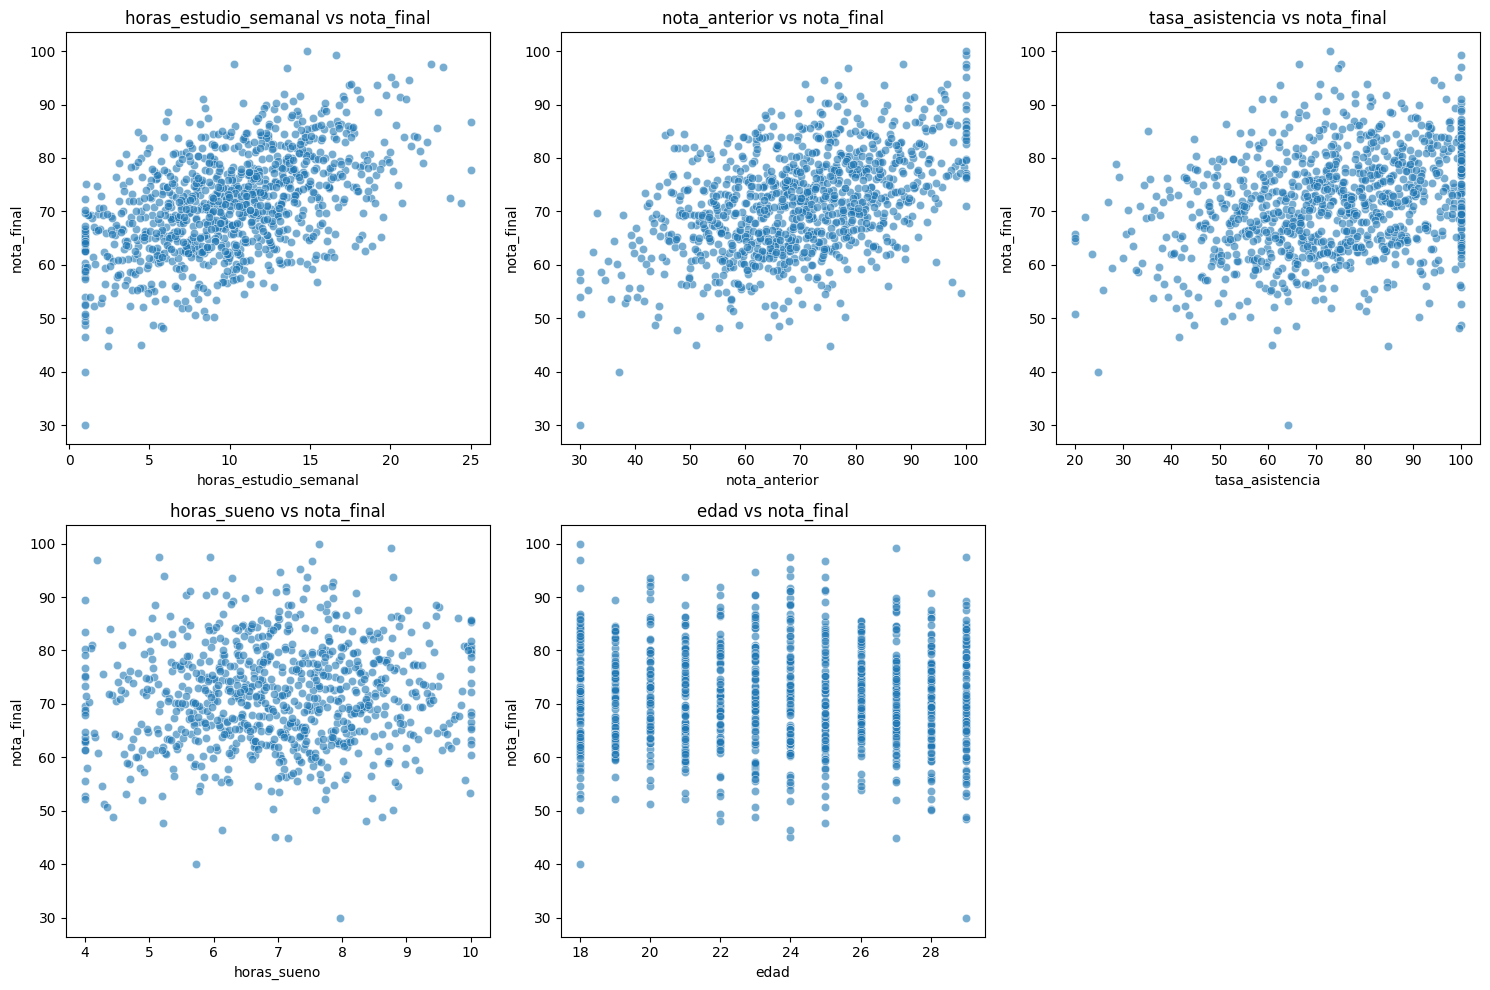

In [34]:
# Gráficos de dispersión entre variables numéricas y nota_final
plt.figure(figsize=(15, 10))

for i, columna in enumerate(variables_numericas_predictoras, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(data=df, x=columna, y="nota_final", alpha=0.6)
    plt.title(f"{columna} vs nota_final")
    plt.xlabel(columna)
    plt.ylabel("nota_final")

plt.tight_layout()
plt.show()


### Relación visual entre variables numéricas y nota_final

Los gráficos de dispersión permiten observar visualmente si existe una posible relación entre cada variable numérica y la variable objetivo `nota_final`.

Si los puntos muestran una tendencia ascendente, podría existir una relación positiva.  
Si los puntos muestran una tendencia descendente, podría existir una relación negativa.  
Si los puntos aparecen muy dispersos sin un patrón claro, la relación visual entre ambas variables sería más débil.

Este análisis ayuda a identificar qué variables podrían aportar más información al modelo de regresión lineal.

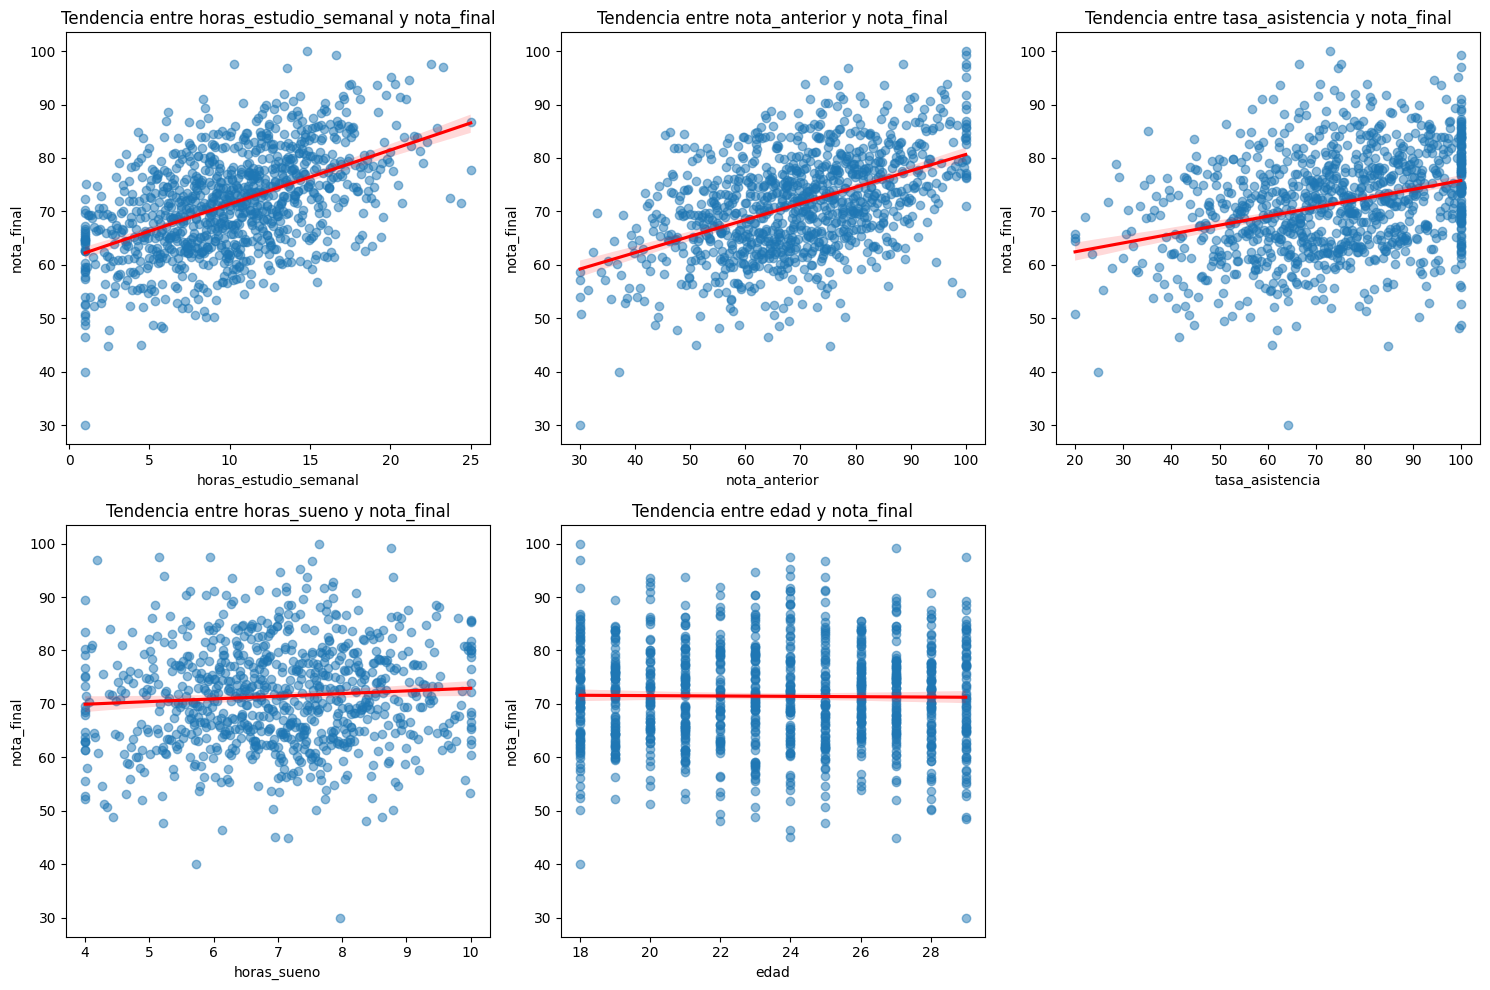

In [38]:
# Ahora agregamos la línea de tendencia a los gráficos de dispersión para observar la relación entre las variables numéricas y la nota_final.

plt.figure(figsize=(15, 10))

for i, columna in enumerate(variables_numericas_predictoras, 1):
    plt.subplot(2, 3, i)
    sns.regplot(
        data=df,
        x=columna,
        y="nota_final",
        scatter_kws={"alpha": 0.5},
        line_kws={"color": "red"}
    )
    plt.title(f"Tendencia entre {columna} y nota_final")
    plt.xlabel(columna)
    plt.ylabel("nota_final")

plt.tight_layout()
plt.show()


### Tendencia lineal con nota_final

Los gráficos con línea de tendencia permiten analizar de forma más clara si existe una relación aproximadamente lineal entre las variables numéricas y `nota_final`.

Este análisis es especialmente útil porque el modelo de regresión solicitado en el proyecto es una regresión lineal, por lo que resulta conveniente comprobar si algunas variables presentan una relación lineal con la variable objetivo.

Las variables que muestren una tendencia más clara podrían tener mayor importancia en el modelo de regresión.

### 4.3 Correlación numérica con nota_final

In [37]:
# Cálculo de correlaciones entre variables numéricas y nota_final
correlacion_nota_final = (
    df[variables_numericas_predictoras + ["nota_final"]]
    .corr(numeric_only=True)["nota_final"]
    .sort_values(ascending=False)
)

correlacion_nota_final


nota_final               1.000000
horas_estudio_semanal    0.513565
nota_anterior            0.469787
tasa_asistencia          0.316773
horas_sueno              0.074635
edad                    -0.012204
Name: nota_final, dtype: float64

### Correlación con nota_final

La correlación permite medir la intensidad y dirección de la relación lineal entre las variables numéricas y `nota_final`.

Los valores cercanos a 1 indican una relación positiva fuerte, mientras que los valores cercanos a -1 indican una relación negativa fuerte.  
Los valores cercanos a 0 indican una relación lineal débil o inexistente.

Este análisis permite identificar qué variables numéricas podrían estar más relacionadas con la nota final de los estudiantes.

### 4.4 Visualización de la correlación numérica con nota_final

Para que la correlación numérica sea más clara, lo que vamos a hacer es una representación gráfica mediante un gráfico de barras.

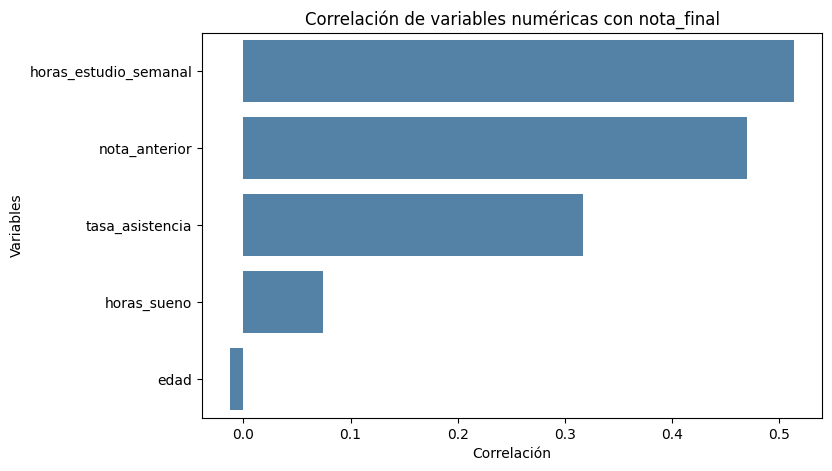

In [39]:
# Visualización de las correlaciones con nota_final
correlacion_nota_final_sin_objetivo = correlacion_nota_final.drop("nota_final")

plt.figure(figsize=(8, 5))

sns.barplot(
    x=correlacion_nota_final_sin_objetivo.values,
    y=correlacion_nota_final_sin_objetivo.index,
    color="steelblue"
)

plt.title("Correlación de variables numéricas con nota_final")
plt.xlabel("Correlación")
plt.ylabel("Variables")

plt.show()

### Visualización de la correlación con nota_final

El gráfico de barras permite comparar de forma sencilla la relación lineal de cada variable numérica con `nota_final`.

Las variables con barras más alejadas de cero presentan una relación lineal más marcada con la nota final.  
Esta información será útil para interpretar posteriormente el comportamiento del modelo de regresión lineal.

### 4.5 Relación entre variables categóricas y nota_final

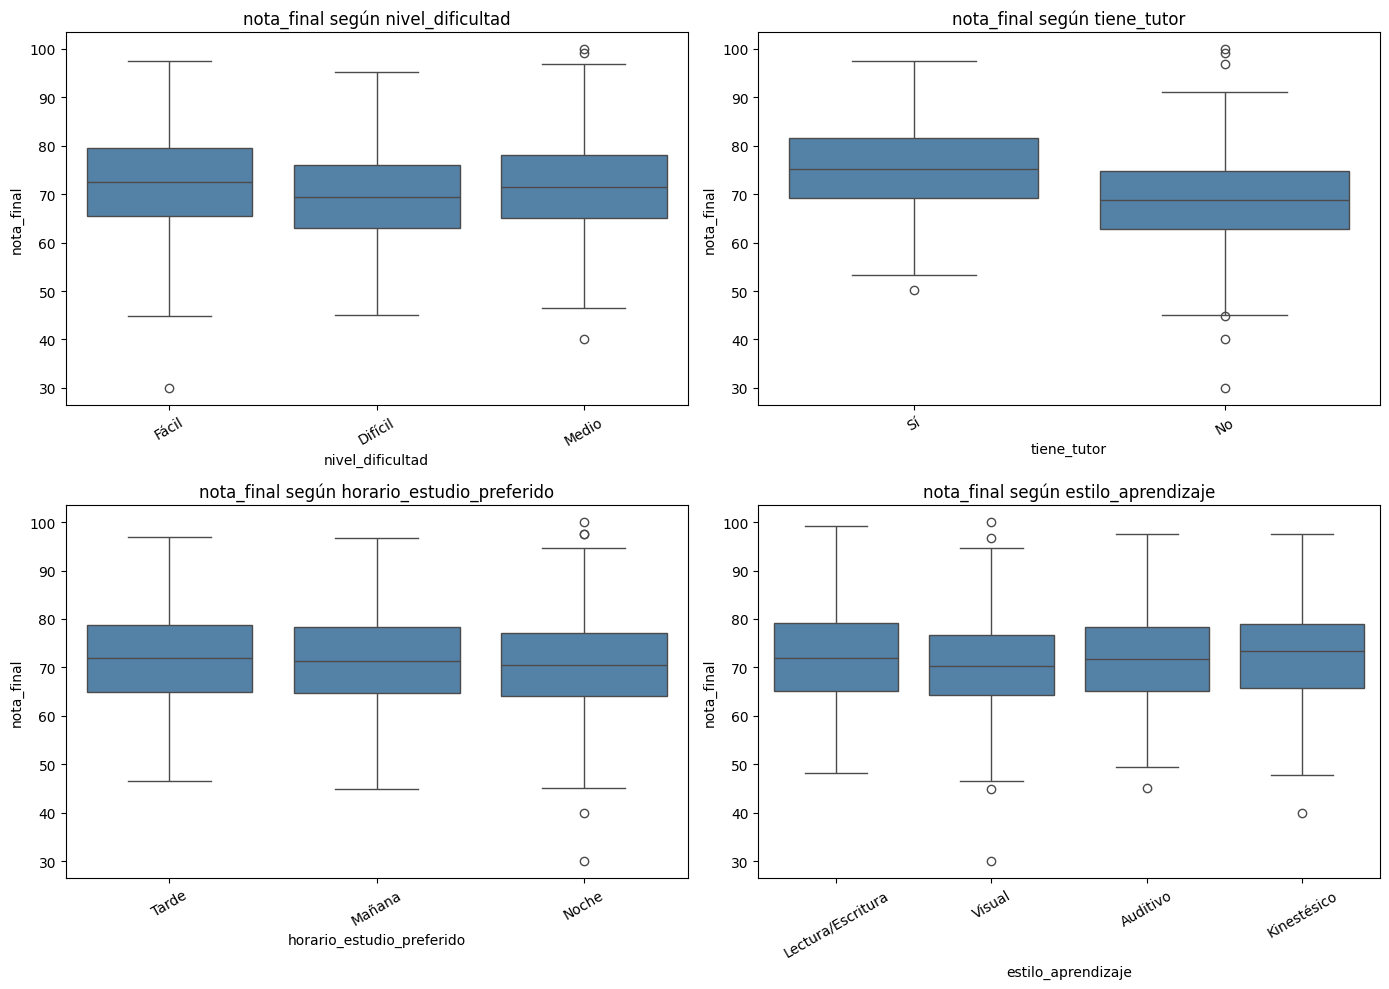

In [41]:
# Boxplots de nota_final según variables categóricas
plt.figure(figsize=(14, 10))

for i, columna in enumerate(variables_categoricas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x=columna, y="nota_final", color="steelblue")
    plt.title(f"nota_final según {columna}")
    plt.xlabel(columna)
    plt.ylabel("nota_final")
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Relación entre variables categóricas y nota_final

Los boxplots permiten comparar la distribución de `nota_final` entre las diferentes categorías de cada variable categórica.

Este análisis ayuda a observar si existen diferencias visibles en la nota final según el nivel de dificultad, la existencia de tutor, el horario de estudio preferido o el estilo de aprendizaje.

Si las medianas o los rangos entre categorías son diferentes, podría indicar que esa variable categórica aporta información relevante para explicar la nota final.

### 4.6 Media de nota_final por categoría

In [42]:
# Media de nota_final para cada categoría de las variables categóricas
for columna in variables_categoricas:
    print("=" * 60)
    print(f"Media de nota_final según {columna}")
    print(
        df.groupby(columna, dropna=False)["nota_final"]
        .mean()
        .round(2)
        .sort_values(ascending=False)
    )
    print()

Media de nota_final según nivel_dificultad
nivel_dificultad
Fácil      72.50
Medio      71.49
Difícil    69.48
Name: nota_final, dtype: float64

Media de nota_final según tiene_tutor
tiene_tutor
Sí    75.29
No    68.84
Name: nota_final, dtype: float64

Media de nota_final según horario_estudio_preferido
horario_estudio_preferido
NaN       72.37
Tarde     71.71
Mañana    71.60
Noche     70.81
Name: nota_final, dtype: float64

Media de nota_final según estilo_aprendizaje
estilo_aprendizaje
Lectura/Escritura    72.59
Kinestésico          72.53
Auditivo             71.82
Visual               70.53
NaN                  68.71
Name: nota_final, dtype: float64



### Media de nota_final por categoría

El cálculo de la media de `nota_final` por categoría permite complementar la información visual obtenida mediante los boxplots.

De esta forma se puede comparar de manera más directa si determinados grupos presentan notas finales medias superiores o inferiores.

Este análisis no implica causalidad, pero sí puede ayudar a identificar patrones relevantes que conviene tener en cuenta en las siguientes fases del proyecto.

### 4.7 Conclusiones del análisis bivariante respecto a nota_final

El análisis bivariante respecto a `nota_final` permite identificar qué variables parecen estar más relacionadas con el rendimiento académico final de los estudiantes.

En primer lugar, al analizar las variables numéricas, se observa que `horas_estudio_semanal` presenta la correlación positiva más alta con `nota_final`, con un valor aproximado de 0.51. Esto indica que, en general, los estudiantes que dedican más horas al estudio semanal tienden a obtener una nota final más alta.

La variable `nota_anterior` también muestra una relación positiva relevante con `nota_final`, con una correlación aproximada de 0.47. Este resultado sugiere que el rendimiento académico previo puede ser un buen indicador del rendimiento final.

Por otro lado, `tasa_asistencia` presenta una correlación positiva moderada, cercana a 0.32. Aunque su relación con la nota final es menor que la observada en las horas de estudio o en la nota anterior, sigue mostrando cierta asociación positiva con el rendimiento académico.

En cambio, las variables `horas_sueno` y `edad` muestran una relación muy débil con `nota_final`. En el caso de `horas_sueno`, la correlación es baja, aproximadamente 0.07, mientras que `edad` presenta una correlación prácticamente nula y ligeramente negativa, alrededor de -0.01. Esto indica que, dentro de este dataset, estas variables no parecen tener una relación lineal clara con la nota final.

Respecto a las variables categóricas, se observan algunas diferencias en la media de `nota_final` según las categorías. 

En `nivel_dificultad`, los estudiantes con categoría `Fácil` presentan una media ligeramente superior, aproximadamente 72.50, mientras que la categoría `Difícil` muestra una media algo inferior, alrededor de 69.48. No obstante, las diferencias no parecen extremadamente marcadas.

En la variable `tiene_tutor`, sí se aprecia una diferencia más clara. Los estudiantes que tienen tutor presentan una media de `nota_final` aproximada de 75.29, mientras que los estudiantes que no tienen tutor presentan una media cercana a 68.84. Esta diferencia sugiere que disponer de tutor podría estar relacionado con un mejor rendimiento académico, aunque no se puede afirmar causalidad únicamente con este análisis exploratorio.

En cuanto a `horario_estudio_preferido`, las diferencias entre categorías son reducidas. Las medias de `nota_final` para `Tarde`, `Mañana` y `Noche` se encuentran en valores similares, entre aproximadamente 70.81 y 71.71. Por tanto, esta variable no parece mostrar grandes diferencias en la nota final según el horario de estudio informado.

Por último, en `estilo_aprendizaje`, las categorías `Lectura/Escritura` y `Kinestésico` presentan medias ligeramente superiores, alrededor de 72.5, mientras que `Visual` muestra una media algo menor, próxima a 70.53. Aun así, las diferencias entre estilos no son muy elevadas, por lo que esta variable deberá analizarse con cautela en fases posteriores.

En conjunto, las variables que parecen tener una relación más clara con `nota_final` son `horas_estudio_semanal`, `nota_anterior`, `tasa_asistencia` y `tiene_tutor`. Estas variables podrían aportar información relevante al modelo de regresión lineal. Sin embargo, estas relaciones deben interpretarse como asociaciones observadas en el análisis exploratorio y no como relaciones causales.